# Model Evaluation — UCI Bank Marketing Dataset

**Project:** CAP182 Capstone - STADIOEquities First-Deposit Activation  
**Part:** C - Model Evaluation  
**Input:** `data/processed/bank_marketing_features.csv`

---

## 1. Evaluation Overview

The STADIOEquities project focuses on the customer activation problem, specifically the challenge of identifying registered users who do not make their first deposit.

The public UCI Bank Marketing dataset is used as a structural proxy for this problem. Its binary target indicates whether a client subscribed to a term deposit and is therefore used to demonstrate the classification process for a financial conversion outcome. The dataset is not used to make conclusions about actual STADIOEquities customers.

Two classification models were developed in the previous stage:

- **Model 1:** Logistic Regression
- **Model 2:** Gradient Boosting Classifier

The purpose of this evaluation stage is to assess the performance of both models using consistent evaluation measures, compare their results, examine their classification behaviour and consider the implications of the results for the project's data-science objective.

Because the target variable is imbalanced, accuracy is not considered sufficient on its own. Precision, recall, F1-score and ROC-AUC are therefore also used to provide a more complete assessment of model performance.

In [1]:
#Importing libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

**1.1 Evaluation Configuration**

The evaluation uses the same modelling configuration established during the model development stage. A fixed random state and stratified sampling are used to ensure that the evaluation can be reproduced and that the class distribution is maintained across the training and test sets.

The same evaluation metrics are applied to both models so that their performance can be compared consistently.

In [4]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5

print("Evaluation configuration:")
print("Random state:", RANDOM_STATE)
print("Test size:", TEST_SIZE)
print("Cross-validation folds:", N_SPLITS)

Evaluation configuration:
Random state: 42
Test size: 0.2
Cross-validation folds: 5


## 2. Load and Verify the Evaluation Dataset

The evaluation stage uses the feature-engineered dataset produced in the previous stage. This ensures that both models are evaluated using the same prepared dataset.

The dataset contains the engineered predictors and the binary target variable `y_binary`. The target follows the orientation established during model development:

- `0` = client did not subscribe to the term deposit
- `1` = client subscribed to the term deposit

The target represents the conversion outcome in the UCI Bank Marketing dataset and is used only as a structural proxy for the STADIOEquities first-deposit activation problem.

**2.1 Load the Feature-Engineered Dataset**

The feature-engineered dataset is loaded from the processed data folder. This file is the output of the feature-engineering stage and contains the variables used by both classification models.

In [5]:
# Load the feature-engineered dataset produced by the previous stage
INPUT_PATH = "data/processed/bank_marketing_features.csv"

df = pd.read_csv(INPUT_PATH)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 45211
Columns: 51


**2.2 Verifying the Target Variable**

Before evaluating the models, the target variable is checked to confirm that it contains the expected binary classes and that the class distribution is consistent with the model development stage.

The target distribution is important because the dataset contains substantially more observations in class 0 than class 1. This class imbalance means that accuracy alone may provide an incomplete picture of model performance.

In [6]:
# Checking the number and proportion of observations in each target class
target_counts = df["y_binary"].value_counts().sort_index()
target_percentages = df["y_binary"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
})

target_summary

,count,percentage
y_binary,,
0,39922,88.3
1,5289,11.7


**2.3 Separate Predictors and Target**

The target variable is separated from the predictor variables so that the evaluation uses the same modelling structure established during the model-development stage.

In [7]:
# Separating the target variable from the predictor variables
X = df.drop(columns=["y_binary"])
y = df["y_binary"]

print("Predictor variables:", X.shape[1])
print("Observations:", X.shape[0])
print("Target classes:", sorted(y.unique()))

Predictor variables: 50
Observations: 45211
Target classes: [0, 1]


**2.4 Recreate the Train/Test Split**

The same stratified 80/20 train/test split used during model development is recreated using `random_state=42`.

Stratification preserves approximately the same proportion of the two target classes in both the training and held-out test sets. Using the same split ensures that both models are evaluated on the same observations.

In [8]:
# Recreating the stratified 80/20 split used during model development
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training observations:", X_train.shape[0])
print("Test observations:", X_test.shape[0])

# Check that stratification maintained the target distribution
print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training observations: 36168
Test observations: 9043

Training class proportions:
y_binary
0    0.883
1    0.117
Name: proportion, dtype: float64

Test class proportions:
y_binary
0    0.883
1    0.117
Name: proportion, dtype: float64


## 3. Evaluation Criteria

The models are evaluated using multiple performance measures because the target variable is imbalanced, with approximately 88.3% of observations belonging to class 0 and 11.7% belonging to class 1.

Using accuracy alone could therefore give an incomplete view of model performance. The evaluation considers accuracy, precision, recall, F1-score and ROC-AUC.

These measures are interpreted together rather than relying on a single metric.

**3.1 Performance Metrics**

**Accuracy** measures the proportion of all observations that are classified correctly. Because the dataset is imbalanced, accuracy is considered alongside the other metrics rather than used as the sole measure of performance.

**Precision** measures the proportion of observations predicted as class 1 that are actually class 1. It indicates how reliable the model's positive predictions are.

**Recall** measures the proportion of actual class 1 observations that the model correctly identifies. It indicates how effectively the model detects observations belonging to the positive class.

**F1-score** is the harmonic mean of precision and recall. It provides a single measure that balances the two when both types of performance are important.

**ROC-AUC** measures the model's ability to distinguish between the two classes across different classification thresholds. Unlike accuracy, precision, recall and F1-score at a fixed threshold, ROC-AUC evaluates the ranking ability of the model across thresholds.

Because the project's broader objective concerns identifying customers associated with non-activation, recall and precision are particularly important to consider when interpreting the classification results. However, the current public dataset defines class 1 as the conversion outcome, so the reported metrics retain that target orientation.

**3.2 Cross-Validation Framework**

Five-fold stratified cross-validation is used on the training data to assess model performance across multiple validation subsets.

Stratification maintains the proportion of the two target classes within each fold. The held-out test set remains separate from cross-validation and is used only for the final performance assessment.

The same cross-validation structure and performance metrics are applied to both models to support a consistent comparison.

In [9]:
# Creating the stratified cross validation framework used for both models
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Define the same performance measures for both classification models
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

print("Cross-validation folds:", N_SPLITS)
print("Scoring metrics:", list(scoring.keys()))

Cross-validation folds: 5
Scoring metrics: ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


## 4. Model 1 — Logistic Regression Performance

Logistic Regression was developed as the first classification model because the project has a binary outcome and the method provides a relatively interpretable baseline for classification.

The model uses the same configuration established during model development: `StandardScaler` followed by `LogisticRegression`, with `random_state=42` and `max_iter=1000`.

The model is evaluated using the five-fold stratified cross-validation framework defined above, followed by evaluation on the held-out test set.

### 4.1 Build the Logistic Regression Model

A pipeline is used to combine standardisation and Logistic Regression. Standardisation is included within the pipeline so that the scaling operation is fitted only to the training data during each cross-validation fold, preventing information from the validation folds from influencing the scaling process.

In [10]:
# Building the Logistic Regression pipeline used during model development
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

# Fitting the model using the training data
logistic_model.fit(X_train, y_train)

print("Logistic Regression model fitted successfully.")

Logistic Regression model fitted successfully.


**4.2 Cross-Validation Performance**

Five-fold stratified cross-validation is applied to the training data using the evaluation framework defined in Section 3.

The mean performance across the five validation folds provides an estimate of how consistently the Logistic Regression model performs on different subsets of the training data.

In [11]:
# Evaluating Logistic Regression across the five stratified cross-validation folds
logistic_cv_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# Calculating the mean training and validation performance across folds
logistic_cv_summary = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "training_mean": [
        logistic_cv_results["train_accuracy"].mean(),
        logistic_cv_results["train_precision"].mean(),
        logistic_cv_results["train_recall"].mean(),
        logistic_cv_results["train_f1"].mean(),
        logistic_cv_results["train_roc_auc"].mean()
    ],
    "validation_mean": [
        logistic_cv_results["test_accuracy"].mean(),
        logistic_cv_results["test_precision"].mean(),
        logistic_cv_results["test_recall"].mean(),
        logistic_cv_results["test_f1"].mean(),
        logistic_cv_results["test_roc_auc"].mean()
    ]
})

logistic_cv_summary.round(4)

,metric,training_mean,validation_mean
0,Accuracy,0.8922,0.8917
1,Precision,0.6357,0.6271
2,Recall,0.1846,0.1829
3,F1-score,0.2861,0.2830
4,ROC-AUC,0.7747,0.7698


**4.3 Interpretation of Cross Validation Results**

The Logistic Regression model produced similar training and validation performance across the reported metrics. The relatively small differences between the training and validation results provide an initial indication that the model is not showing a large training-validation performance gap during cross-validation.

The validation ROC-AUC of approximately 0.77 indicates that the model has useful ability to distinguish between the two outcome classes in the proxy dataset. However, the validation recall for class 1 is approximately 18%, indicating that the model identifies only a relatively small proportion of the actual class 1 observations at the default classification threshold.

Precision is higher than recall, indicating that the model's positive predictions are more selective than its overall ability to identify all class 1 observations.

These results describe performance on the UCI Bank Marketing proxy dataset and should not be interpreted as evidence about actual STADIOEquities customer activation behaviour.

**4.4 Held-Out Test Performance**

After cross-validation, the fitted Logistic Regression model is evaluated on the held-out test set.

The test set was not used during cross validation or model fitting and therefore provides an independent estimate of performance on unseen observations.

The same five performance metrics are calculated so that the test results can be compared with the cross-validation results.

In [13]:
# Generating class predictions and predicted probabilities for the held-out test set
logistic_test_predictions = logistic_model.predict(X_test)
logistic_test_probabilities = logistic_model.predict_proba(X_test)[:, 1]

# Calculate the test-set performance metrics
logistic_test_accuracy = accuracy_score(y_test, logistic_test_predictions)
logistic_test_precision = precision_score(y_test, logistic_test_predictions)
logistic_test_recall = recall_score(y_test, logistic_test_predictions)
logistic_test_f1 = f1_score(y_test, logistic_test_predictions)
logistic_test_roc_auc = roc_auc_score(y_test, logistic_test_probabilities)

# Displaying the test-set metrics
logistic_test_summary = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "test_set": [
        logistic_test_accuracy,
        logistic_test_precision,
        logistic_test_recall,
        logistic_test_f1,
        logistic_test_roc_auc
    ]
})

logistic_test_summary.round(4)

,metric,test_set
0,Accuracy,0.8934
1,Precision,0.6556
2,Recall,0.1871
3,F1-score,0.2912
4,ROC-AUC,0.7789


**4.5 Confusion Matrix and Classification Report**

The confusion matrix provides a more detailed view of how the Logistic Regression model classified the two outcome classes.

The classification report provides precision, recall and F1-score separately for each class. This is particularly useful for the current dataset because the target classes are imbalanced.

In [14]:
# Calculating the confusion matrix for the held-out test set
logistic_confusion = confusion_matrix(y_test, logistic_test_predictions)

print("Logistic Regression Confusion Matrix:")
print(logistic_confusion)

# Display class-specific precision, recall and F1-score
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_test_predictions,
        target_names=["Class 0", "Class 1"]
    )
)

Logistic Regression Confusion Matrix:
[[7881  104]
 [ 860  198]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.90      0.99      0.94      7985
     Class 1       0.66      0.19      0.29      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043



**4.6 Interpretation of Test-Set Performance**

The Logistic Regression model achieved an accuracy of 89.34%, precision of 65.56%, recall of 18.71%, F1-score of 29.12% and ROC-AUC of 77.89% on the held-out test set.

Accuracy should be interpreted cautiously because 88.30% of the observations belong to class 0. The model's precision for class 1 was 65.56%, meaning that approximately two-thirds of observations predicted as class 1 were correctly classified. However, recall for class 1 was 18.71%, meaning that the model identified fewer than one-fifth of the actual class 1 observations at the default 0.50 classification threshold.

The confusion matrix shows that the model correctly classified 7,881 of the 7,985 class 0 observations and 198 of the 1,058 class 1 observations. This indicates that the model was considerably more effective at identifying class 0 observations than class 1 observations at the default threshold.

The ROC-AUC of 77.89% indicates that the model has useful ability to distinguish between the two outcome classes across classification thresholds. The ROC-AUC should therefore be considered alongside the threshold dependent precision, recall and F1-score.

The similarity between the cross validation and held-out test results provides an indication of consistent performance on unseen observations. These results describe the UCI Bank Marketing proxy dataset and should not be interpreted as evidence of actual STADIOEquities customer behaviour.

**4.7 Logistic Regression Evaluation Summary**

The following table summarises the Logistic Regression cross-validation and held-out test performance. These results will be carried forward into the comparison with the Gradient Boosting model.

In [16]:
# Combining the cross-validation and held-out test results for later model comparison
logistic_evaluation_summary = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "cross_validation": [
        logistic_cv_results["test_accuracy"].mean(),
        logistic_cv_results["test_precision"].mean(),
        logistic_cv_results["test_recall"].mean(),
        logistic_cv_results["test_f1"].mean(),
        logistic_cv_results["test_roc_auc"].mean()
    ],
    "test_set": [
        logistic_test_accuracy,
        logistic_test_precision,
        logistic_test_recall,
        logistic_test_f1,
        logistic_test_roc_auc
    ]
})

logistic_evaluation_summary.round(4)

,metric,cross_validation,test_set
0,Accuracy,0.8917,0.8934
1,Precision,0.6271,0.6556
2,Recall,0.1829,0.1871
3,F1-score,0.2830,0.2912
4,ROC-AUC,0.7698,0.7789


## 5. Model 2 — Gradient Boosting Performance

Gradient Boosting was developed as the second classification model. Unlike Logistic Regression, which models a linear relationship between the predictors and the outcome on the transformed feature space, Gradient Boosting uses an ensemble of decision trees to model more complex and non-linear relationships.

The model uses the same training and test data, random state and evaluation framework as Logistic Regression. This allows the performance of the two models to be compared on an equivalent basis.

**5.1 Build the Gradient Boosting Model**

The Gradient Boosting Classifier is fitted using the training data. No feature scaling is applied because tree-based models do not require numerical standardisation.

In [17]:
# Building the Gradient Boosting model used during model development
gradient_boosting_model = GradientBoostingClassifier(
    random_state=RANDOM_STATE
)

# Fitting the model using the training data
gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model fitted successfully.")

Gradient Boosting model fitted successfully.


**5.2 Cross-Validation Performance**

The Gradient Boosting model is evaluated using the same five-fold stratified cross-validation framework used for Logistic Regression.

Using the same folds and performance measures allows the models to be compared consistently while assessing how stable their performance is across different subsets of the training data.

In [18]:
# Evaluating Gradient Boosting across the five stratified cross-validation folds
gradient_boosting_cv_results = cross_validate(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# Calculating the mean training and validation performance across folds
gradient_boosting_cv_summary = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "training_mean": [
        gradient_boosting_cv_results["train_accuracy"].mean(),
        gradient_boosting_cv_results["train_precision"].mean(),
        gradient_boosting_cv_results["train_recall"].mean(),
        gradient_boosting_cv_results["train_f1"].mean(),
        gradient_boosting_cv_results["train_roc_auc"].mean()
    ],
    "validation_mean": [
        gradient_boosting_cv_results["test_accuracy"].mean(),
        gradient_boosting_cv_results["test_precision"].mean(),
        gradient_boosting_cv_results["test_recall"].mean(),
        gradient_boosting_cv_results["test_f1"].mean(),
        gradient_boosting_cv_results["test_roc_auc"].mean()
    ]
})

gradient_boosting_cv_summary.round(4)

,metric,training_mean,validation_mean
0,Accuracy,0.8976,0.8947
1,Precision,0.6980,0.6588
2,Recall,0.2196,0.2075
3,F1-score,0.3341,0.3154
4,ROC-AUC,0.8046,0.7882


**5.3 Interpretation of Cross-Validation Results**

The Gradient Boosting model achieved a mean validation accuracy of approximately 89.47%, precision of 65.88%, recall of 20.75%, F1-score of 31.54% and ROC-AUC of 78.82% across the five cross-validation folds.

Training performance is consistently higher than validation performance, but the differences are relatively small. This provides an initial indication that the model does not exhibit a large training-validation performance gap during cross-validation.

The validation results show that the model can distinguish between the two outcome classes in the proxy dataset, while recall for class 1 remains relatively limited at the default classification threshold.

The Gradient Boosting cross-validation results will be compared with the Logistic Regression results after the held-out test performance has also been evaluated.

**5.4 Held-Out Test Performance**

After cross-validation, the fitted Gradient Boosting model is evaluated on the held-out test set.

The test observations were not used during cross-validation or model fitting and therefore provide an independent assessment of model performance on unseen observations.

The same five performance metrics used for Logistic Regression are calculated to allow a consistent comparison between the two models.

In [19]:
# Generating class predictions and predicted probabilities for the held-out test set
gradient_boosting_test_predictions = gradient_boosting_model.predict(X_test)
gradient_boosting_test_probabilities = gradient_boosting_model.predict_proba(X_test)[:, 1]

# Calculating the test-set performance metrics
gradient_boosting_test_accuracy = accuracy_score(
    y_test,
    gradient_boosting_test_predictions
)

gradient_boosting_test_precision = precision_score(
    y_test,
    gradient_boosting_test_predictions
)

gradient_boosting_test_recall = recall_score(
    y_test,
    gradient_boosting_test_predictions
)

gradient_boosting_test_f1 = f1_score(
    y_test,
    gradient_boosting_test_predictions
)

gradient_boosting_test_roc_auc = roc_auc_score(
    y_test,
    gradient_boosting_test_probabilities
)

# Displaying the test-set performance metrics
gradient_boosting_test_summary = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "test_set": [
        gradient_boosting_test_accuracy,
        gradient_boosting_test_precision,
        gradient_boosting_test_recall,
        gradient_boosting_test_f1,
        gradient_boosting_test_roc_auc
    ]
})

gradient_boosting_test_summary.round(4)

,metric,test_set
0,Accuracy,0.8952
1,Precision,0.6708
2,Recall,0.2042
3,F1-score,0.3130
4,ROC-AUC,0.7979


**5.5 Confusion Matrix and Classification Report**

The confusion matrix provides a detailed view of the Gradient Boosting model's classification results on the held-out test set.

The classification report provides precision, recall and F1-score separately for each class. These results are considered alongside the overall performance metrics because of the imbalance between the two target classes.

In [20]:
# Calculating the confusion matrix for the held-out test set
gradient_boosting_confusion = confusion_matrix(
    y_test,
    gradient_boosting_test_predictions
)

print("Gradient Boosting Confusion Matrix:")
print(gradient_boosting_confusion)

# Displaying class-specific precision, recall and F1-score
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        gradient_boosting_test_predictions,
        target_names=["Class 0", "Class 1"]
    )
)

Gradient Boosting Confusion Matrix:
[[7879  106]
 [ 842  216]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.90      0.99      0.94      7985
     Class 1       0.67      0.20      0.31      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.60      0.63      9043
weighted avg       0.88      0.90      0.87      9043



**5.6 Interpretation of Test-Set Performance**

The Gradient Boosting model achieved an accuracy of approximately 89.52%, precision of 67.08%, recall of 20.42%, F1-score of 31.30% and ROC-AUC of 79.79% on the held-out test set.

Accuracy is interpreted cautiously because class 0 represents approximately 88.3% of the observations. The precision of 67.08% for class 1 indicates that approximately two-thirds of observations predicted as class 1 were correctly classified. The recall of 20.42% indicates that the model identified approximately one-fifth of the actual class 1 observations at the default 0.50 classification threshold.

The confusion matrix shows that the model correctly classified 7,879 of the 7,985 class 0 observations and 216 of the 1,058 class 1 observations. The model therefore identifies substantially more class 0 than class 1 observations at the default threshold.

The ROC-AUC of 79.79% indicates that the model has useful ability to distinguish between the two outcome classes across classification thresholds.

The similarity between the cross-validation and held-out test results provides an indication of consistent performance on unseen observations. These results describe the UCI Bank Marketing proxy dataset and should not be interpreted as evidence of actual STADIOEquities customer behaviour.

**5.7 Gradient Boosting Evaluation Summary**

The following table summarises the Gradient Boosting cross-validation and held-out test performance. These results will be carried forward into the final comparison with Logistic Regression.

In [21]:
# Combining the cross-validation and held-out test results for later model comparison
gradient_boosting_evaluation_summary = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "cross_validation": [
        gradient_boosting_cv_results["test_accuracy"].mean(),
        gradient_boosting_cv_results["test_precision"].mean(),
        gradient_boosting_cv_results["test_recall"].mean(),
        gradient_boosting_cv_results["test_f1"].mean(),
        gradient_boosting_cv_results["test_roc_auc"].mean()
    ],
    "test_set": [
        gradient_boosting_test_accuracy,
        gradient_boosting_test_precision,
        gradient_boosting_test_recall,
        gradient_boosting_test_f1,
        gradient_boosting_test_roc_auc
    ]
})

gradient_boosting_evaluation_summary.round(4)

,metric,cross_validation,test_set
0,Accuracy,0.8947,0.8952
1,Precision,0.6588,0.6708
2,Recall,0.2075,0.2042
3,F1-score,0.3154,0.3130
4,ROC-AUC,0.7882,0.7979


## 6. Comparison of Model 1 and Model 2

The two models are compared using the same cross-validation and held-out test-set metrics. Using a common evaluation framework allows the differences in model performance to be examined directly.

The comparison considers accuracy, precision, recall, F1-score and ROC-AUC. Because the target variable is imbalanced, the comparison does not rely on accuracy alone.

**6.1 Visual Comparison of Model Performance**

The performance of the Logistic Regression and Gradient Boosting models is compared using accuracy, precision, recall, F1-score and ROC-AUC.

The chart shows both cross-validation and held-out test performance. The held-out test results provide the final assessment of how each model performed on previously unseen observations, while the cross-validation results provide an indication of consistency during model development.

Visualising the results makes it easier to compare the models across multiple evaluation measures rather than relying on accuracy alone.odels.

In [27]:
# Combine the evaluation results from both models into one comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (CV)",
        "Logistic Regression (Test)",
        "Gradient Boosting (CV)",
        "Gradient Boosting (Test)"
    ],
    "Accuracy": [
        logistic_cv_results["test_accuracy"].mean(),
        logistic_test_accuracy,
        gradient_boosting_cv_results["test_accuracy"].mean(),
        gradient_boosting_test_accuracy
    ],
    "Precision": [
        logistic_cv_results["test_precision"].mean(),
        logistic_test_precision,
        gradient_boosting_cv_results["test_precision"].mean(),
        gradient_boosting_test_precision
    ],
    "Recall": [
        logistic_cv_results["test_recall"].mean(),
        logistic_test_recall,
        gradient_boosting_cv_results["test_recall"].mean(),
        gradient_boosting_test_recall
    ],
    "F1-score": [
        logistic_cv_results["test_f1"].mean(),
        logistic_test_f1,
        gradient_boosting_cv_results["test_f1"].mean(),
        gradient_boosting_test_f1
    ],
    "ROC-AUC": [
        logistic_cv_results["test_roc_auc"].mean(),
        logistic_test_roc_auc,
        gradient_boosting_cv_results["test_roc_auc"].mean(),
        gradient_boosting_test_roc_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression (CV),0.8917,0.6271,0.1829,0.2830,0.7698
1,Logistic Regression (Test),0.8934,0.6556,0.1871,0.2912,0.7789
2,Gradient Boosting (CV),0.8947,0.6588,0.2075,0.3154,0.7882
3,Gradient Boosting (Test),0.8952,0.6708,0.2042,0.3130,0.7979


**6.2 Interpretation of Model Performance**

The results show that Gradient Boosting produced higher performance values than Logistic Regression across the reported measures on the held-out test set. Gradient Boosting achieved an accuracy of 89.52%, precision of 67.08%, recall of 20.42%, F1-score of 31.30% and ROC-AUC of 79.79%. Logistic Regression achieved 89.34% accuracy, 65.56% precision, 18.71% recall, 29.12% F1-score and 77.89% ROC-AUC.

The differences between the models are relatively modest, but Gradient Boosting shows a consistent improvement across the five measures. The ROC-AUC results also indicate stronger overall discrimination between the two target classes on the proxy dataset.

Accuracy should not be interpreted independently because approximately 88.3% of observations belong to class 0. The relatively low recall for class 1 also indicates that both models miss a substantial proportion of the positive cases at the default classification threshold.

The results describe model performance on the UCI Bank Marketing dataset and should therefore not be interpreted as evidence of equivalent performance on actual STADIOEquities customer data.

**6.3 Confusion Matrix Comparison**

The confusion matrices provide a visual comparison of how the two models classified the held-out test observations.

Each matrix shows the number of correct and incorrect classifications for the two target classes. In this proxy dataset, class 0 represents clients who did not subscribe to the term deposit, while class 1 represents clients who subscribed.

The comparison is particularly useful because the target variable is imbalanced. It allows the classification errors for each class to be examined directly rather than relying only on aggregate performance measures.

**6.3 Comparison of Classification Behaviour**

The confusion matrices provide additional information about how the models classify the two outcome classes at the default 0.50 threshold.

Logistic Regression correctly classified 7,881 of the 7,985 class 0 observations and 198 of the 1,058 class 1 observations.

Gradient Boosting correctly classified 7,879 of the 7,985 class 0 observations and 216 of the 1,058 class 1 observations.

The models therefore show very similar performance for class 0, while Gradient Boosting identifies a larger number of class 1 observations at the default threshold. This difference contributes to its higher recall and F1-score.

However, both models still fail to identify a substantial proportion of the actual class 1 observations. This demonstrates why the evaluation should consider more than accuracy.

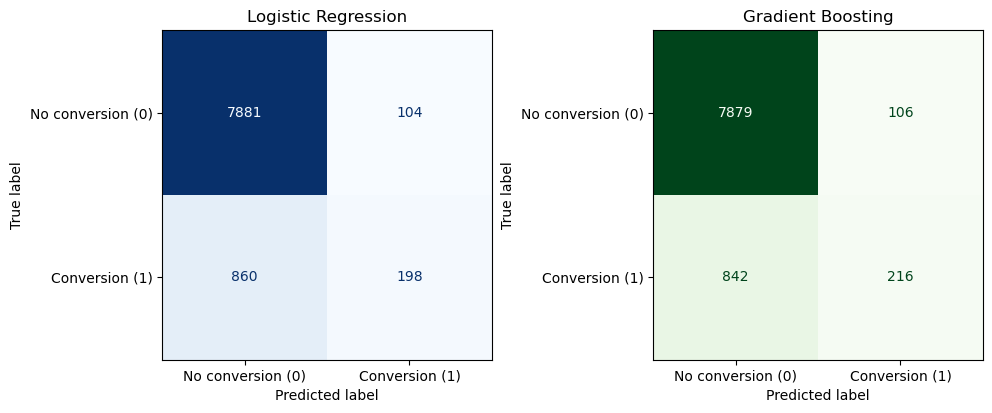

Logistic Regression — TN, FP, FN, TP: [7881  104  860  198]
Gradient Boosting   — TN, FP, FN, TP: [7879  106  842  216]


In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrices for both models
lr_cm = confusion_matrix(y_test, logistic_test_predictions)
gb_cm = confusion_matrix(y_test, gradient_boosting_test_predictions)

# Display both confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

ConfusionMatrixDisplay(
    lr_cm,
    display_labels=["No conversion (0)", "Conversion (1)"]
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)

axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    gb_cm,
    display_labels=["No conversion (0)", "Conversion (1)"]
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False
)

axes[1].set_title("Gradient Boosting")

plt.tight_layout()
plt.show()

# Print the four confusion-matrix components for reference
print("Logistic Regression — TN, FP, FN, TP:", lr_cm.ravel())
print("Gradient Boosting   — TN, FP, FN, TP:", gb_cm.ravel())

**6.4 Interpretation of Classification Behaviour**

The confusion matrices show that both models correctly classified the large majority of class 0 observations. Logistic Regression correctly classified 7,881 of the 7,985 class 0 observations, while Gradient Boosting correctly classified 7,879.

For class 1, Logistic Regression correctly identified 198 of the 1,058 observations, while Gradient Boosting correctly identified 216. Gradient Boosting therefore identified more class 1 observations while producing a similar number of false positives.

These results are consistent with the recall measures reported above. Logistic Regression achieved a class 1 recall of 18.71%, while Gradient Boosting achieved 20.42%. Therefore, both models identify only a relatively small proportion of the positive class when using the default classification threshold, although Gradient Boosting identifies more positive observations.

The confusion matrices provide additional context for the aggregate metrics because they show where the classification errors occur. As with the other results, these findings relate to the UCI Bank Marketing proxy dataset rather than actual STADIOEquities customers.

In [23]:
# Displaying both confusion matrices side by side for direct comparison
confusion_comparison = pd.DataFrame(
    {
        "Logistic Regression": logistic_confusion.ravel(),
        "Gradient Boosting": gradient_boosting_confusion.ravel()
    },
    index=[
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)"
    ]
)

confusion_comparison

,Logistic Regression,Gradient Boosting
True Negative (TN),7881,7879
False Positive (FP),104,106
False Negative (FN),860,842
True Positive (TP),198,216


**6.5 Generalisation Across Cross-Validation and Test Results**

The cross-validation and held-out test results are relatively close for both models.

For Logistic Regression, ROC-AUC increased from 76.98% during cross-validation to 77.89% on the test set. For Gradient Boosting, ROC-AUC increased from 78.82% during cross-validation to 79.79% on the test set.

The other evaluation measures also show relatively small differences between the cross-validation and test results. This consistency provides an indication that the models produced similar performance on the held-out observations to that observed during model development.

Gradient Boosting shows a higher training performance than validation performance, as observed earlier in the model-development stage. However, the results do not show a large training-validation gap across the reported measures.

Overall, the consistency between the cross-validation and test results provides supporting evidence that the observed model performance is not solely dependent on the particular training split used.

# 7. Model Interpretation

Model evaluation determines how accurately the models classify the proxy conversion outcome, while model interpretation examines the information that contributes to those predictions.

This distinction is important for the project because the objective is not only to develop a predictive model, but also to identify factors associated with financial conversion that could inform the investigation of customer activation.

The Logistic Regression model provides directly interpretable coefficients and odds ratios. The Gradient Boosting model provides feature-importance measures that were examined during the model-development stage. The findings are considered together to identify areas of overlap between the two modelling approaches.

All interpretations are based on the UCI Bank Marketing dataset, which is being used as a structural proxy for the STADIOEquities activation problem. The findings therefore demonstrate the interpretation process and should not be treated as evidence about actual STADIOEquities customers.omers.

**7.1 Logistic Regression Coefficients and Odds Ratios**

Logistic Regression provides coefficients that indicate the direction and strength of association between each predictor and the predicted outcome.

To make these coefficients easier to interpret, they are also converted into odds ratios. An odds ratio above 1 indicates higher predicted odds of the positive outcome relative to the reference category, while an odds ratio below 1 indicates lower predicted odds.

The coefficients and odds ratios describe associations within the fitted model and should not be interpreted as evidence of causation. For categorical variables, the interpretation is relative to the reference category created during feature engineering.

In [36]:
# Extracting the fitted Logistic Regression coefficients
logistic_coefficients = logistic_model.named_steps["logistic_regression"].coef_[0]

# Creating a table containing coefficients and corresponding odds ratios
coefficient_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_coefficients
})

coefficient_table["Odds Ratio"] = np.exp(
    coefficient_table["Coefficient"]
)

# Sorting by coefficient to identify the strongest negative associations
strongest_negative = coefficient_table.sort_values(
    "Coefficient"
).head(10)

print("Strongest negative associations:")
strongest_negative.round(4)

Strongest negative associations:


,Feature,Coefficient,Odds Ratio
27,contact_unknown,-0.5821,0.5588
28,month_aug,-0.2560,0.7741
24,housing_yes,-0.2411,0.7858
36,month_nov,-0.2294,0.7950
32,month_jul,-0.2267,0.7972
35,month_may,-0.2104,0.8103
3,campaign,-0.2096,0.8109
31,month_jan,-0.1900,0.8269
44,age_band_50-59,-0.1894,0.8275
43,age_band_40-49,-0.1623,0.8502


In [37]:
# Identifying the features with the strongest positive associations
strongest_positive = coefficient_table.sort_values(
    "Coefficient",
    ascending=False
).head(10)

print("Strongest positive associations:")
strongest_positive.round(4)

Strongest positive associations:


,Feature,Coefficient,Odds Ratio
40,poutcome_success,0.3954,1.4850
41,poutcome_unknown,0.2333,1.2627
47,balance_band_1000-4999,0.1996,1.2209
5,previously_contacted,0.1890,1.2081
21,education_tertiary,0.1313,1.1403
46,balance_band_0-999,0.1215,1.1292
34,month_mar,0.1037,1.1093
48,balance_band_5000-9999,0.0919,1.0963
20,education_secondary,0.0744,1.0772
37,month_oct,0.0705,1.0731


**7.1 Interpretation of Logistic Regression Results**

The Logistic Regression results identify several variables associated with the proxy conversion outcome. Among the strongest positive associations, `poutcome_success` has a coefficient of 0.3954 and an odds ratio of 1.4850. Holding the other variables in the model constant, observations in this category have approximately 1.49 times the odds of the positive outcome relative to the relevant reference category.

Other positive associations include `poutcome_unknown`, `balance_band_1000-4999` and `previously_contacted`, with odds ratios of 1.2627, 1.2209 and 1.2081 respectively.

The strongest negative association is `contact_unknown`, with a coefficient of -0.5821 and an odds ratio of 0.5588. Other negative associations include `housing_yes`, `campaign` and several month and age-band variables.

The categorical variables are interpreted relative to their omitted reference categories. These results describe associations within the fitted model and do not establish that any variable causes the observed outcome.

The results also illustrate why Logistic Regression was useful as one of the project's models: its coefficients and odds ratios provide a relatively transparent way of describing the predictive relationships identified by the model.

**7.2 Interpretation Across the Two Models**

The two modelling approaches provide complementary forms of interpretation. Logistic Regression provides coefficients and odds ratios that describe the direction and relative strength of associations, while Gradient Boosting identifies features according to their contribution to the model's predictive decisions.

There is some overlap between the signals identified by the two models. In particular, `poutcome_success` was the strongest positive Logistic Regression association and was also the most important feature in the Gradient Boosting model. `contact_unknown`, month-related variables, `housing_yes` and balance-related variables also appeared among the more influential predictors across the modelling approaches.

This overlap provides some consistency in the predictive patterns identified in the proxy dataset. However, feature importance and regression coefficients should not be interpreted as causal effects. In addition, the practical usefulness of a predictor depends on whether equivalent information would be available at the point when an activation intervention is made.

For the STADIOEquities problem, these findings therefore demonstrate the type of information that a future model could provide rather than identifying actual drivers of first-deposit activation. Validation using STADIOEquities customer data would be required before these types of relationships could inform an operational activation strategy.

# 8. Limitations

The results of this project should be interpreted within the limitations of the dataset, modelling approach and available business information.

### 8.1 Proxy Dataset

The UCI Bank Marketing dataset was used as a structural proxy because actual STADIOEquities customer data was not available for this project. Although the dataset contains a financial conversion outcome and supports the modelling methodology, its variables and customer behaviour are not identical to those of STADIOEquities. The model results therefore demonstrate the data science approach rather than provide predictions for actual STADIOEquities customers.

### 8.2 Target and Class Imbalance

The proxy target is imbalanced, with approximately 88% of observations belonging to the non-conversion class and 12% to the conversion class. As a result, accuracy alone does not provide a sufficient assessment of model performance. Precision, recall, F1-score, ROC-AUC and confusion matrices were therefore considered. Both models also failed to identify a substantial proportion of the positive cases at the default classification threshold.

### 8.3 Feature Availability and Timing

Some variables may only become available after a customer interaction has taken place. For an operational STADIOEquities activation model, predictors would need to be available at the point when an intervention decision is made. The variable `duration` was excluded during feature engineering because it represents information known after a contact interaction and could introduce leakage for an early-intervention use case.

### 8.4 Model Development Constraints

The models were developed using standard Logistic Regression and Gradient Boosting configurations without extensive hyperparameter tuning or resampling techniques. This keeps the comparison reproducible and consistent, but further model development could potentially improve predictive performance when actual STADIOEquities data becomes available.

### 8.5 Business Validation

The analysis does not contain information about the financial cost of interventions, available customer-service capacity, or the business impact of false positives and false negatives. Consequently, a classification threshold cannot be selected solely from the model results. Any operational deployment would require these business considerations to be evaluated alongside predictive performance.

### 8.6 Generalisation to STADIOEquities

The findings should not be interpreted as evidence that the identified variables will have the same relationships with first-deposit activation at STADIOEquities. Actual STADIOEquities data would need to be collected, validated and tested before the modelling approach could be used to support customer activation decisions.

# 9. Conclusion

This project investigated whether customer and behavioural data could be used to identify patterns associated with financial conversion, with the broader objective of supporting STADIOEquities' first-deposit activation problem.

Two classification models were developed and evaluated using the UCI Bank Marketing dataset as a structural proxy: Logistic Regression and Gradient Boosting. Both models demonstrated predictive ability on the proxy dataset. Gradient Boosting achieved slightly higher performance on the held-out test set, including a ROC-AUC of 0.7979 compared with 0.7789 for Logistic Regression. Logistic Regression, however, provides more directly interpretable coefficients and odds ratios.

The confusion matrices and recall results also show that both models identified only a relatively small proportion of the positive conversion cases at the default classification threshold. This demonstrates why model evaluation should consider multiple performance measures rather than accuracy alone, particularly when the target classes are imbalanced.

The interpretation analysis identified several variables associated with the proxy conversion outcome, with some overlap between the Logistic Regression and Gradient Boosting results. These findings provide an example of how predictive modelling and model interpretation can be combined to investigate factors associated with financial conversion.

For STADIOEquities, the next step would be to apply the same data science process to validated customer, onboarding, behavioural, funding, marketing and support data. This would allow the organisation to determine whether similar patterns exist among its own registered customers and whether they can be used to identify users who are unlikely to make a first deposit.

Overall, the project demonstrates a reproducible approach to investigating customer activation through data preparation, feature engineering, supervised classification, model evaluation and interpretation, while recognising that actual STADIOEquities data is required before the approach can be validated for operational use.

In [1]:
git status

SyntaxError: invalid syntax (3528599804.py, line 1)